In [97]:
import numpy as np
import os
import matplotlib.pyplot as plt
from astropy.io import fits
import matplotlib
from scipy import interpolate
import pickle
import glob

import lsd_utils as lsd
homedir = os.path.expanduser("~")
datadir = f"{homedir}/uoedrive/data/gcm_hires/w1049b-sept2025"
c_km_s = 3e5

In [51]:
l_orders = [
    [3.10, 3.15],
    [3.14, 3.19],
    [3.19, 3.24],
    [3.23, 3.27]
]
goodchips = [1]
cd=1
cm=0
nchip = len(goodchips)

Read GCM data and fitted models

In [ ]:
bestmodelname = 't1400g1000f2'
resultdir = f"{homedir}/uoedrive/result/fitted/diamondback"

with open(f'{resultdir}/METIS_W1049B_L_{bestmodelname}.pickle', 'rb') as f:
    data = pickle.load(f)
res = np.loadtxt(f'{resultdir}/METIS_W1049B_L_fitting_results_{bestmodelname}.txt', skiprows=1)
order, obs, chisq, vsini, lld, rv = res.T
rvs = np.nanmedian(rv.reshape(4, 20), axis=1)
rvs

array([1.0090e-07, 1.1450e-10, 8.9025e-09, 1.8350e-05])

Read METIS mock data and fitted models

rvs: [0.]


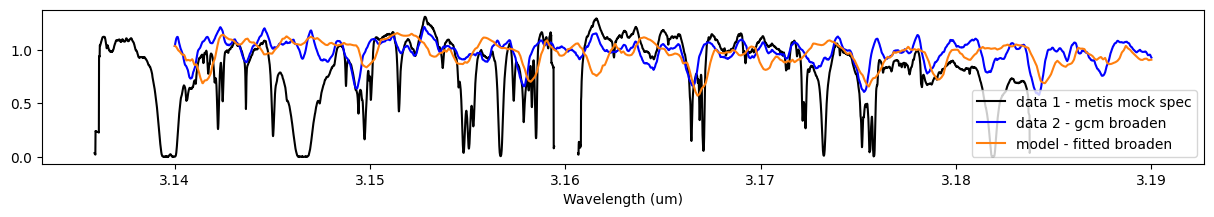

In [ ]:
bestmodelname = 't1400g1000f2'
resultdir = f"{homedir}/uoedrive/result/fitted/diamondback"

with open(f'{resultdir}/METIS_case1_L1_{bestmodelname}.pickle', 'rb') as f:
    metis = pickle.load(f)
res = np.loadtxt(f'{resultdir}/METIS_case1_L1_fitting_results_{bestmodelname}.txt', skiprows=1)
order, obs, chisq, vsini, lld, rv = res.T
rvs = np.nanmedian(rv.reshape(1, 20), axis=1)
print("rvs:",rvs)

t=0
scale_ref = 2900
shift = 0
plt.figure(figsize=(15,2))
plt.plot(metis['chiplams'][t,cm], metis['observed'][t,cm]/scale_ref, color='k', label=f'data 1 - metis mock spec')
plt.plot(data['chiplams'][t,cd], data['observed'][t,cd], color='b', label=f'data 2 - gcm broaden')
plt.plot(data["chiplams"][t,cd]*(1-shift), data['chipmods'][t,cd], color='tab:orange', label=f'model - fitted broaden')
#plt.plot(metis['chiplams'][t,cm]*(1-shift), metis['chipmods'][t,cm]/2800, color='orange', label=f'model - metis mock spec')
plt.xlabel('Wavelength (um)')
plt.legend(loc='lower right');

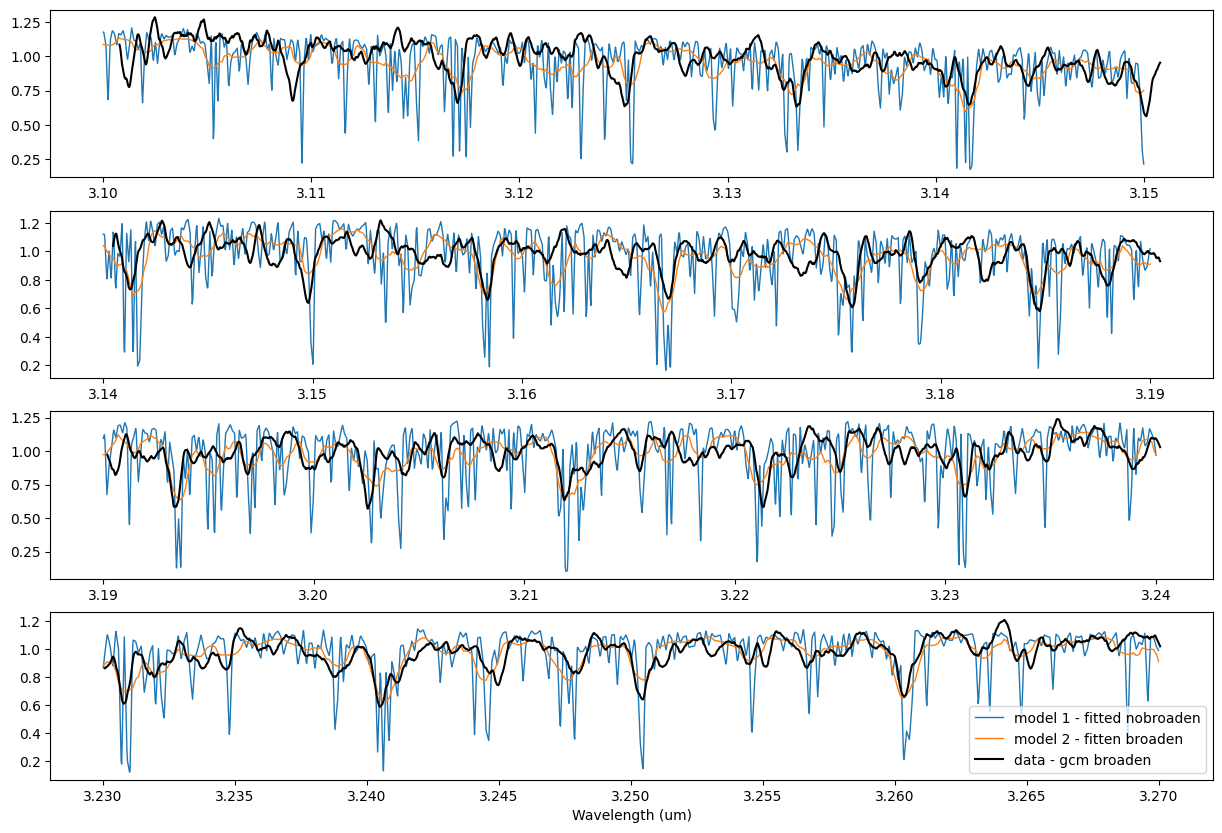

In [118]:
t=0
rv = [25.e-5, 15.e-5, 6e-5, 1.8e-05]
plt.figure(figsize=(15,10))
for c in range(4):
    #wlmin, wlmax = l_orders[c]
    #wlind = np.where((modwl>wlmin) & (modwl<wlmax))[0]
    plt.subplot(4,1,c+1)
    plt.plot(data['chiplams'][t,c], data['chipmodnobroad'][t,c], color='tab:blue', lw=1, label=f'model 1 - fitted nobroaden')
    plt.plot(data['chiplams'][t,c], data['chipmods'][t,c], color='tab:orange', lw=1, label=f'model 2 - fitten broaden')
    plt.plot(data['chiplams'][t,c]*(1+rv[c]), data['observed'][t,c], color='k', label=f'data - gcm broaden')
plt.xlabel('Wavelength (um)')
plt.legend()

Prepare Doppler imaging input: GCM data + METIS error

In [111]:
wlmin = max(data['chiplams'][t,cd,0], metis['chiplams'][t,cm,0])
wlmax = min(data['chiplams'][t,cd,-1], metis['chiplams'][t,cm,-1])
print(wlmin, wlmax)

3.140005860635608 3.183800000000002


In [158]:
# Interpolate to same wavelength grid
nobs=20
nchip=1
goodchips=[1]
npix=4000
shift=-15e-5
chiplams = np.empty((nobs, nchip, npix), dtype=np.float32)
observed = np.empty((nobs, nchip, npix), dtype=np.float32)
template = np.empty((nobs, nchip, npix), dtype=np.float32)
mock_observed = np.empty((nobs, nchip, npix), dtype=np.float32)
error = np.empty((nobs, nchip, npix), dtype=np.float32)
for cm, cd in enumerate(goodchips):
    print(cd, cm)
    for t in range(nobs):
        #wlmin, wlmax = m_orders[c]
        #print('chip:', c, "wlmin:", wlmin, "wlmax:", wlmax)
        lams_lin = np.linspace(wlmin, wlmax, npix, dtype=np.float32)
        spline_observed = interpolate.interp1d(data['chiplams'][t,cd], data['observed'][t,cd], kind='linear', bounds_error=False, fill_value='extrapolate')
        spline_chipmodnobroad = interpolate.interp1d(data['chiplams'][t,cd]*(1+shift), data['chipmodnobroad'][t,cd], kind='linear', bounds_error=False, fill_value='extrapolate')
        spline_error = interpolate.interp1d(metis['chiplams'][t,cm], metis['error'][t,cm], kind='linear', bounds_error=False, fill_value='extrapolate')
        chiplams[t,cm] = lams_lin
        observed[t,cm] = spline_observed(lams_lin)
        template[t,cm] = spline_chipmodnobroad(lams_lin)
        error[t,cm] = spline_error(lams_lin)

        # add noise
        noise = np.random.normal(0, error[t,cm])
        mock_observed[t,cm] = observed[t,cm] * scale_ref + np.nan_to_num(noise, nan=0.0)
        mock_observed[0,0] /= np.nanmedian(mock_observed[0,0])


1 0


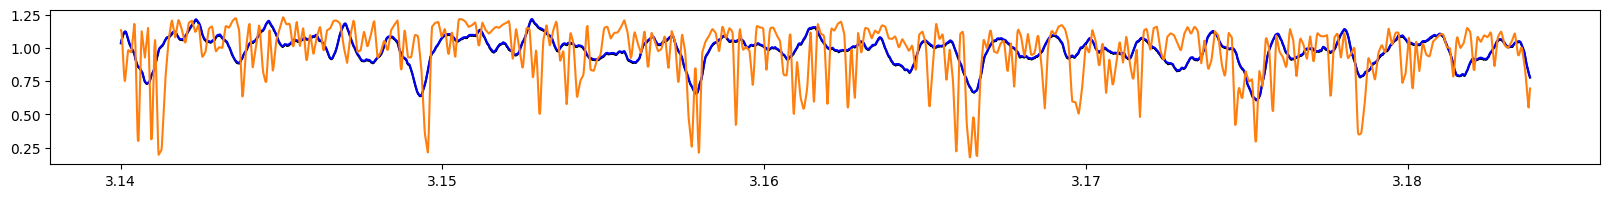

In [159]:
plt.figure(figsize=(20,2))
shift = 1.5e-4
shift = 0
plt.plot(chiplams[0,0], mock_observed[0,0], color='k', label=f'mock observed')
plt.plot(chiplams[0,0], observed[0,0], color='b', label=f'original observed') 
plt.plot(chiplams[0,0], template[0,0], color='tab:orange', label=f'template - no broaden')

Find lines and cont

In [82]:
# --- Equivalent width integration ---
def equivalent_width(wave, flux):
    # assumes flux normalized to continuum = 1
    return np.trapz(1 - flux, wave)

# --- Upper-envelope continuum fit ---
def fit_continuum_upper_envelope(wave, flux, order=3, segment_width=50, percentile=95):
    """
    Fit a smooth polynomial continuum approximating the upper envelope.
    """
    n = len(wave)
    segs = np.arange(0, n, segment_width)
    upper_x, upper_y = [], []

    for i in segs:
        j = min(i + segment_width, n)
        upper_x.append(np.median(wave[i:j]))
        upper_y.append(np.percentile(flux[i:j], percentile))

    coeffs = np.polyfit(upper_x, upper_y, order)
    continuum = np.polyval(coeffs, wave)
    return continuum

# --- Slope-change-based line detection ---
def detect_lines(
    wave, flux, continuum_order=5,
    depth_threshold=0.05, window=5
):
    """
    Detect absorption lines where the flux slope changes from negative to positive.

    Parameters
    ----------
    wave : ndarray
        Wavelength array (Å)
    flux : ndarray
        Observed flux array
    depth_threshold : float
        Minimum drop below continuum (e.g. 0.01 = 1%)
    window : int
        Half-width (pixels) for local EW integration
    """

    # --- Fit continuum and normalize ---
    continuum = fit_continuum_upper_envelope(
        wave, flux, order=continuum_order,
        segment_width=50, percentile=95
    )
    norm_flux = flux / continuum

    # --- Compute numerical derivative ---
    dflux = np.diff(norm_flux)

    centers, ews = [], []

    # --- Detect slope sign reversals (decreasing → increasing) ---
    for i in range(1, len(dflux)):
        if dflux[i-1] < 0 and dflux[i] > 0:
            # candidate local minimum at i
            # check depth threshold
            if (1 - norm_flux[i]) > depth_threshold:
                i1, i2 = max(i - window, 0), min(i + window, len(wave) - 1)
                x, y = wave[i1:i2], norm_flux[i1:i2]
                ew = equivalent_width(x, y)
                centers.append(wave[i])
                ews.append(ew)

    # --- Filter nonphysical EWs ---
    centers = np.array(centers)
    ews = np.array(ews)
    mask = ews > 1e-4
    centers = centers[mask]
    ews = ews[mask]

    return continuum, centers, ews


In [142]:
# prepare wl for line search
wlstep = 0.5*1e-4
wl_lin = np.arange(wlmin, wlmax+wlstep, wlstep, dtype=np.float32)
wl_lin_ang = wl_lin * 1e4  # in micron

# prepare spectrum for line search
spec_all = []
wl = np.loadtxt(f"{homedir}/uoedrive/data/gcm_hires/w1049b-sept2025/high-resolution/wavelength_micron.txt")
for t in range(20):
    spec = np.loadtxt(f"{homedir}/uoedrive/data/gcm_hires/w1049b-sept2025/high-resolution/spectrum_erg.s.cm3_nobroaden_time{t+1}.txt")
    spec_all.append(spec)
spec_all = np.array(spec_all)
spec_mean = np.nanmedian(spec_all,axis=0)
interp_func = interpolate.interp1d(wl, spec_mean, kind='linear', bounds_error=False, fill_value=0.0)
spec_lin = interp_func(wl_lin)

# find lines
my_cont, my_lineloc, my_lineew = detect_lines(wl_lin_ang, spec_lin, window=1)
my_lineloc.shape, my_lineew.shape, my_lineew.min(), my_lineew.max(), my_lineew.mean()

/var/folders/jm/dmx123p56254c5gy18wgtyh00000gn/T/ipykernel_28062/812503451.py:45: RankWarning: Polyfit may be poorly conditioned
  continuum = fit_continuum_upper_envelope(


((285,), (285,), 0.016624931576249696, 0.36956269133434555, 0.1084553273522014)

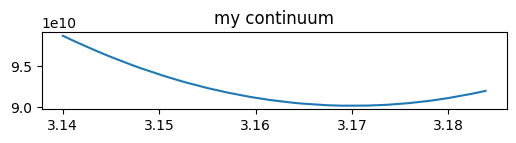

In [143]:
# plot continuum
plt.figure(figsize=(6,1))
plt.plot(wl_lin, my_cont)
plt.title("my continuum")
my_spline = interpolate.UnivariateSpline(wl_lin, my_cont, s=0.0, k=1.0)

Compute LSD

In [144]:
# Compute LSD velocity grid:
nk=150
goodchips=[1]
#pad=50
wav_angs = chiplams[0] * 1e4
dbeta = np.diff(wav_angs).mean()/wav_angs.mean()
dx = dbeta * np.arange(np.floor(-nk/2.+.5), np.floor(nk/2.+.5))
dv = c_km_s*dx # km/s
npix = chiplams.shape[2]
print("dv:", dv.shape)
#print(dv)

dv: (150,)


chip 0 31400.059 31838.0 9932089028698264.0


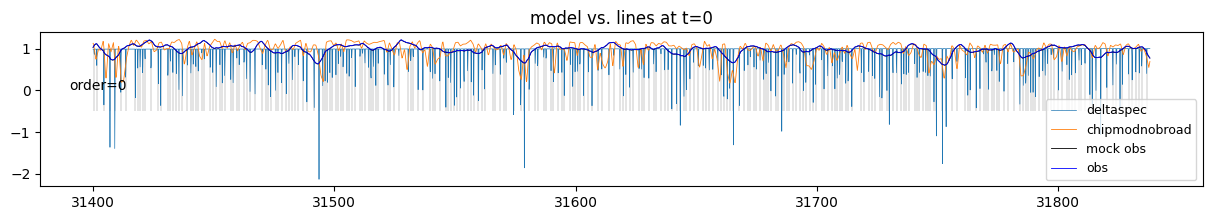

In [162]:
# Check line matching
rv_lsd = [-15e-5]
rv_lsd = [0]

# mock compute LSD:
deltaspecs = np.zeros((nobs, nchip, npix), dtype=float)
for c in range(nchip): 
    cont = my_spline(wav_angs[c])
    print("chip", c, wav_angs[c].min(), wav_angs[c].max(), np.nanmedian(cont))
    cont /= np.nanmedian(cont)
    for t in range(nobs):
        shift = 1. + rv_lsd[c]  # best rv shift for Callie is 9e-5
        deltaspec = lsd.make_deltaspec(my_lineloc*shift, my_lineew, wav_angs[c], verbose=False, cont=cont)
        #_,kerns[t,c],_,_ = lsd.dsa(deltaspec, observed[t,c], nk)
        #_,modkerns[t,c],_,_ = lsd.dsa(deltaspec, template[t,c], nk) 
        deltaspecs[t,c] = deltaspec #/np.abs(np.nanmin(deltaspec))

# plot lines vs. model
plt.figure(figsize=(15, 2*nchip))
t=0
for c in range(nchip):
    plt.subplot(nchip,1,c+1)
    ind = np.where((my_lineloc>=wav_angs[c].min()) & (my_lineloc<=wav_angs[c].max()))
    plt.vlines(my_lineloc[ind], ymin=-0.5, ymax=1, color='gray', lw=0.3)
    plt.plot(wav_angs[c], deltaspecs[t,c], linewidth=0.5, color='C0', label="deltaspec")
    plt.plot(wav_angs[c], template[t,c], linewidth=0.6, color='C1', label="chipmodnobroad")
    plt.plot(wav_angs[c], mock_observed[t,c], linewidth=0.6, color='k', label="mock obs")
    plt.plot(wav_angs[c], observed[t,c], linewidth=0.6, color='b', label="obs")
    plt.text(x=wav_angs[c].min()-10, y=0, s=f"order={c}")
    if c==0:
        plt.title(f"model vs. lines at t={t}")
plt.legend(loc=4, fontsize=9)

chip 0


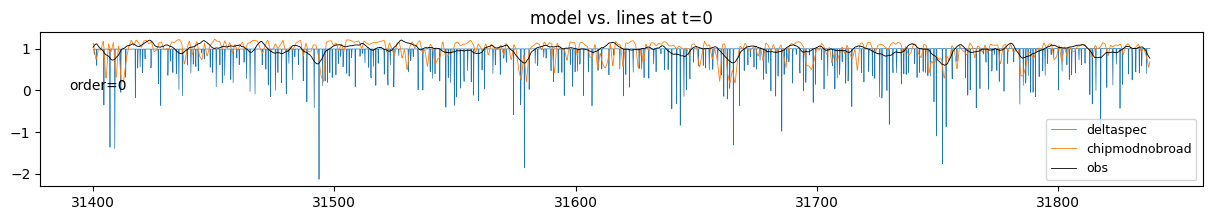

In [168]:
# Compute LSD for real
rv_lsd = [0]

kerns = np.zeros((nobs, nchip, nk), dtype=float)
modkerns = np.zeros((nobs, nchip, nk), dtype=float)
deltaspecs = np.zeros((nobs, nchip, npix), dtype=float)
for c in range(nchip): 
    print("chip", c)
    for t in range(nobs):
        shift = 1. + rv_lsd[c]  # best rv shift for Callie is 9e-5
        cont = my_spline(wav_angs[c])
        cont /= np.nanmedian(cont)
        deltaspec = lsd.make_deltaspec(my_lineloc*shift, my_lineew, wav_angs[c], verbose=False, cont=cont)
    
        _,kerns[t,c],_,_ = lsd.dsa(deltaspec, observed[t,c], nk)
        _,modkerns[t,c],_,_ = lsd.dsa(deltaspec, template[t,c], nk) 
        deltaspecs[t,c] = deltaspec #/np.abs(np.nanmin(deltaspec))

plt.figure(figsize=(15, 2*nchip))
t=0
for c in range(nchip):
    plt.subplot(nchip,1,c+1)
    plt.plot(wav_angs[c], deltaspecs[t,c], linewidth=0.5, color='C0', label="deltaspec")
    plt.plot(wav_angs[c], template[t,c], linewidth=0.6, color='C1', label="chipmodnobroad")
    plt.plot(wav_angs[c], mock_observed[t,c], linewidth=0.6, color='k', label="obs")
    plt.text(x=wav_angs[c].min()-10, y=0, s=f"order={c}")
    if c==0:
        plt.title(f"model vs. lines at t={t}")
plt.legend(loc=4, fontsize=9)
plt.show()

In [171]:
kerns[0,0]

array([-1.15623277e-03, -8.17871788e-04, -7.24742335e-04, -5.30345531e-04,
       -4.93600148e-04, -6.44955453e-04, -4.67677076e-04, -1.77053435e-04,
       -6.61962329e-05,  2.70713512e-04,  5.36854290e-04,  9.30983265e-04,
        1.32372243e-03,  1.73369398e-03,  2.09062342e-03,  2.23536134e-03,
        2.52628976e-03,  2.82173726e-03,  3.19548429e-03,  3.63086880e-03,
        3.84582876e-03,  4.06799600e-03,  4.09444771e-03,  4.52642997e-03,
        4.84585905e-03,  5.08936315e-03,  5.37414181e-03,  5.74125555e-03,
        6.27278602e-03,  6.60977884e-03,  6.91686622e-03,  7.18391575e-03,
        7.58165366e-03,  7.96478638e-03,  8.34390701e-03,  8.75626895e-03,
        9.24942958e-03,  9.91280413e-03,  1.04752373e-02,  1.11597292e-02,
        1.16429909e-02,  1.24047598e-02,  1.29321335e-02,  1.36110221e-02,
        1.44240017e-02,  1.51797506e-02,  1.61885168e-02,  1.72162460e-02,
        1.84425161e-02,  2.00251326e-02,  2.20617647e-02,  2.49621457e-02,
        2.83439835e-02,  

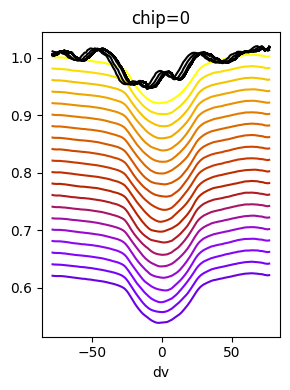

In [169]:
# Plot LSD kernels
gap=0.02
colors = [matplotlib.cm.gnuplot_r(x) for x in np.linspace(0, 1, nobs+4)]
plt.figure(figsize=(nchip*3,4))
for c in range(nchip):
    plt.subplot(1, nchip, c+1)
    for t in range(nobs):
        plt.plot(dv, 1 - kerns[t,c] - gap*t, color=colors[t])
        plt.plot(dv, 1 - modkerns[t,c], color='k')
    plt.title(f"chip={c}")
    plt.xlabel("dv")
plt.tight_layout()

In [ ]:
# Shift kerns to center
cen_modkerns = np.zeros_like(modkerns)
cen_kerns = np.zeros_like(kerns)
for i,c in enumerate(goodchips):
    modkerns_chip = np.median(modkerns[:,i,:], axis=0)
    systematic_rv_offset = (modkerns_chip==modkerns_chip.max()).nonzero()[0][0] - (dv==0).nonzero()[0][0] # find the rv offset
    print("chip:", c, "offset:", systematic_rv_offset)
    for k in range(nobs):
        cen_modkerns[k,i] = np.interp(np.arange(nk), np.arange(nk) - systematic_rv_offset, modkerns[k,i]) # shift ip to center at dv=0
        cen_kerns[k,i] = np.interp(np.arange(nk), np.arange(nk) - systematic_rv_offset, kerns[k,i]) # shift kerns with same amount

In [ ]:
# Contiuum-normalize kerns
obskerns = 1. - cen_kerns
obskerns_norm = np.zeros_like(obskerns)
continuumfit = np.zeros((nobs, nchip, 2))
side = 15
for c in range(nchip):
    for t in range(nobs):
        inds = np.concatenate((np.arange(0, side), np.arange(nk-side, nk)))
        continuumfit[t,c] = np.polyfit(inds, obskerns[t,c,inds], 1)
        obskerns_norm[t,c] = obskerns[t,c] / np.polyval(continuumfit[t,c], np.arange(nk))

intrinsic_profiles = np.array([modkerns[:,i].mean(0) for i in range(nchip)])

In [53]:
# Cut out wings on the side
gap=0.02
s = 40
nk_cut = nk - s*2
dv_cut = dv[s:-s]
obskerns_cut = obskerns_norm[:,:,s:-s]
modkerns_cut = 1. - cen_modkerns[:,:,s:-s]
print("new nk:", nk_cut, dv_cut.shape)

plt.figure(figsize=(nchip*4,4))
for i, c in enumerate(goodchips):
    mean_obskerns = obskerns_cut[:,c].mean(0)
    mean_modkerns = modkerns_cut[:,c].mean(0)
    plt.subplot(1, nchip+1, i+1)
    for t in range(nobs):
        plt.plot(dv_cut, mean_obskerns - gap*t, color="grey", alpha=0.5)
        plt.plot(dv_cut, obskerns_cut[t,c] - gap*t, color=colors[t])
    plt.plot(dv_cut, mean_modkerns, color='k')
    plt.title(f"chip={c}")
    plt.xlabel("dv (km/s)")
plt.subplot(1, nchip+1, nchip+1)
for t in range(nobs):
    plt.plot(dv_cut, np.median(np.median(obskerns_cut,axis=0),axis=0) - gap*t, color="grey", alpha=0.5)
    plt.plot(dv_cut, np.median(obskerns_cut[t,:],axis=0) - gap*t, color=colors[t])
plt.plot(dv_cut, np.median(np.median(modkerns_cut,axis=0),axis=0), color='k')
plt.title(f"L band all chips")
plt.xlabel("dv (km/s)")
plt.tight_layout()

NameError: name 'nk' is not defined

In [ ]:
# Deviation plot
period = 5.2
aspect = 1.7
vmax = 0.004
# store uniform profiles for each chip
uniform_profiles = np.zeros((nchip, nk_cut))

plt.figure(figsize=(nchip*4,2.5))
for i, c in enumerate(goodchips):
    uniform_profiles[i] = np.median(obskerns_cut[:,i], axis=0) # is each chip's mean kern over epoches
    plt.subplot(1,nchip+1,i+1)
    plt.imshow(obskerns_cut[:,i]-uniform_profiles[i], 
        extent=(dv_cut[0], dv_cut[-1], period, 0),
        aspect=int((nk_cut)/period*aspect),
        cmap='YlOrBr',
        vmax=vmax, vmin=-vmax) # positive diff means dark spot
    #plt.xlim(dv_cut.min(), dv_cut.max()),
    plt.xlabel("velocity (km/s)")
    plt.ylabel("Elapsed time (h)")
    plt.colorbar(fraction=0.035)
    plt.title(f"chip={c}")
# plot mean deviation
mean_dev = np.median(np.array([obskerns_cut[:,i]-uniform_profiles[i] for i in range(nchip)]), axis=0) # mean over chips
plt.subplot(1, nchip+1,i+2)
plt.imshow(mean_dev, 
    extent=(dv_cut[0], dv_cut[-1], period, 0),
    aspect=int((nk_cut)/period*aspect),
    cmap='YlOrBr',
    vmax=vmax, vmin=-vmax) # positive diff means dark spot
#plt.xlim(dv.min()+s, dv.max()-s),
plt.xlabel("velocity (km/s)")
plt.ylabel("Elapsed time (h)")
plt.colorbar(fraction=0.035)
plt.title(f"mean deviation")
plt.tight_layout()

Solve Doppler imaging

In [ ]:
import dime
from importlib import reload
reload(dime)
from dime import DopplerImaging

In [ ]:
# Run settings
period = 5.2
timestamps = np.array([
   0.000, 0.278, 0.556, 0.833, 1.111, 1.389, 1.667, 1.944, 2.222,
   2.500, 2.778, 3.056, 3.333, 3.611, 3.889, 4.167, 4.444, 4.722,
   5.000, 5.278])
params_run = {
   'nk': 150, 
   'nobs': 20, 
   'timestamps': timestamps,
   'phases': 2*np.pi*timestamps/period,
   'inc': 80,
   'vsini': 24, 
   'rv': 1e-7, 
   'lld': 0.1, 
   'eqarea': True, 
   'nlat': 10, 
   'nlon': 20, 
   'alpha': 5000}

In [ ]:
# Solve
wav_nm = wav_angs / 10.0  # convert to nm
dmap = DopplerImaging(wav_nm, goodchips, params_dict=params_run, instru="METIS")
dmap.intrinsic_profiles = intrinsic_profiles
dmap.obskerns_norm = obskerns_norm
dmap.solve(create_obs_from_diff=True, solver='scipy')
dmap.plot_mollweide_map(colorbar=True, vmin=80, vmax=120)

In [ ]:
# Estimate S/N of LSD profiles
from scipy.signal import savgol_filter
hw=40
smoothed = savgol_filter(dmap.obskerns_norm, 31, 3)
resid = dmap.obskerns_norm - smoothed
err_pix = np.array([np.abs(resid[:,:,pix] - np.median(resid, axis=2)) for pix in range(nk)]) # error of each pixel in LP by MAD
if int(nk/2-hw) < 0:
    err_pix_linecen = err_pix
else:
    err_pix_linecen = err_pix[int(nk/2-hw):int(nk/2+hw)]
err_LP = 1.4826 * np.median(err_pix_linecen, axis=0) # error of each LP (at each t and chip)

signal = 1 - smoothed.min(axis=2).mean(axis=0) # signal = line depth
noise = np.median(err_LP, axis=0) # mean error of a chip
snr_LP = signal/noise # S/N of LP of each chip
snr_LP